# Preprocessing and Fetaure Enginnering

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = "../data/processed/financial_database.parquet"
OUT_PREP_PATH = "../data/processed/financial_database_preprocessed.parquet"
OUT_FEAT_PATH = "../data/processed/financial_database_features.parquet"

## The Problems

In [3]:
df_raw = pd.read_parquet(RAW_PATH)
df_raw.shape, df_raw.columns.tolist()[:10]

((27650, 36),
 ['date',
  'open',
  'high',
  'low',
  'close',
  'adj_close',
  'volume',
  'sma_50',
  'sma_200',
  'ema_20'])

In [4]:
macro_cols = ["CPIAUCSL", "FEDFUNDS", "GDP"]

df_raw[macro_cols].isna().mean().sort_values(ascending=False)


GDP         0.948282
FEDFUNDS    0.528752
CPIAUCSL    0.511392
dtype: float64

In [25]:
cols = df_raw.columns.tolist()
cols.remove("date")
cols.remove("ticker")
price_cols = cols[:6]
technical_cols = cols[6:17]
# macro is the last 3 columns
fund_cols = cols[17:29]
macro_cols = cols[-3:]
print(fund_cols)

['net_margin', 'operating_margin', 'ebitda_margin', 'asset_turnover', 'roe', 'roa', 'fcf_margin', 'revenue_growth_qoq', 'earnings_growth_qoq', 'fcf_growth_qoq', 'debt_to_equity', 'current_ratio']


### Price distribution

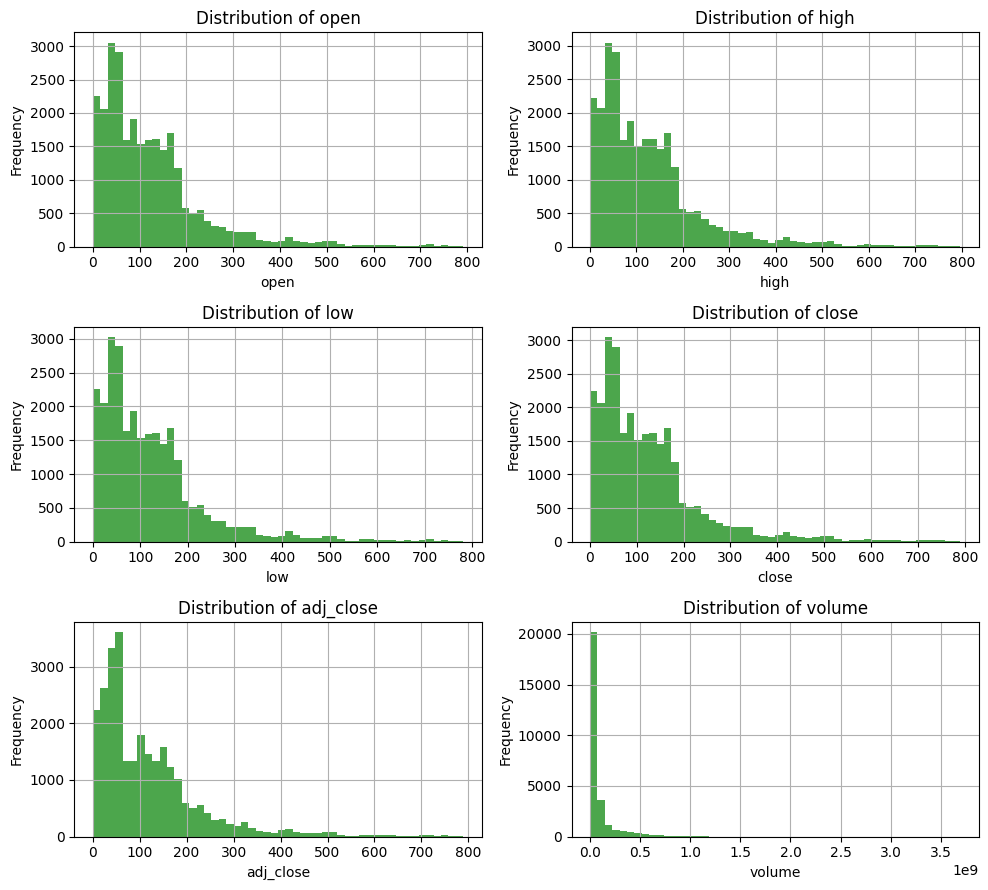

In [22]:
# price distributions (2 plots per row, smaller)

n = len(price_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(price_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Technical Distribution

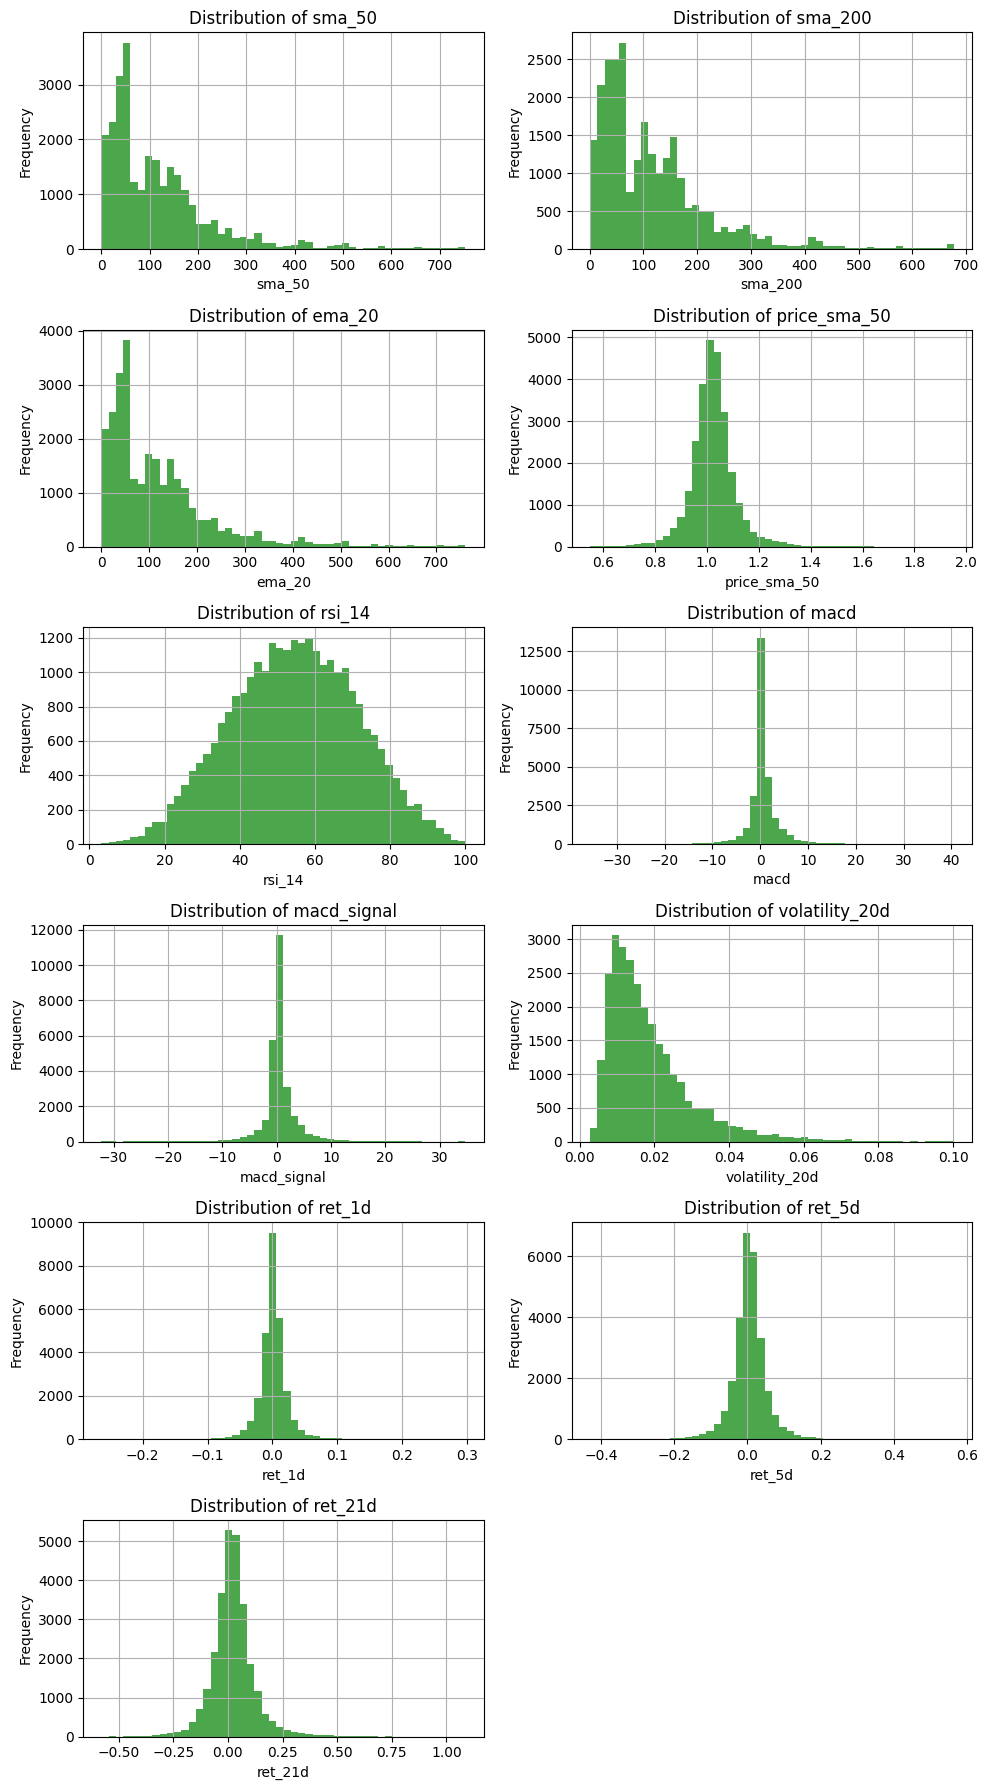

In [21]:
# technical distributions (2 plots per row, smaller)
n = len(technical_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(technical_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Fundamental Dist

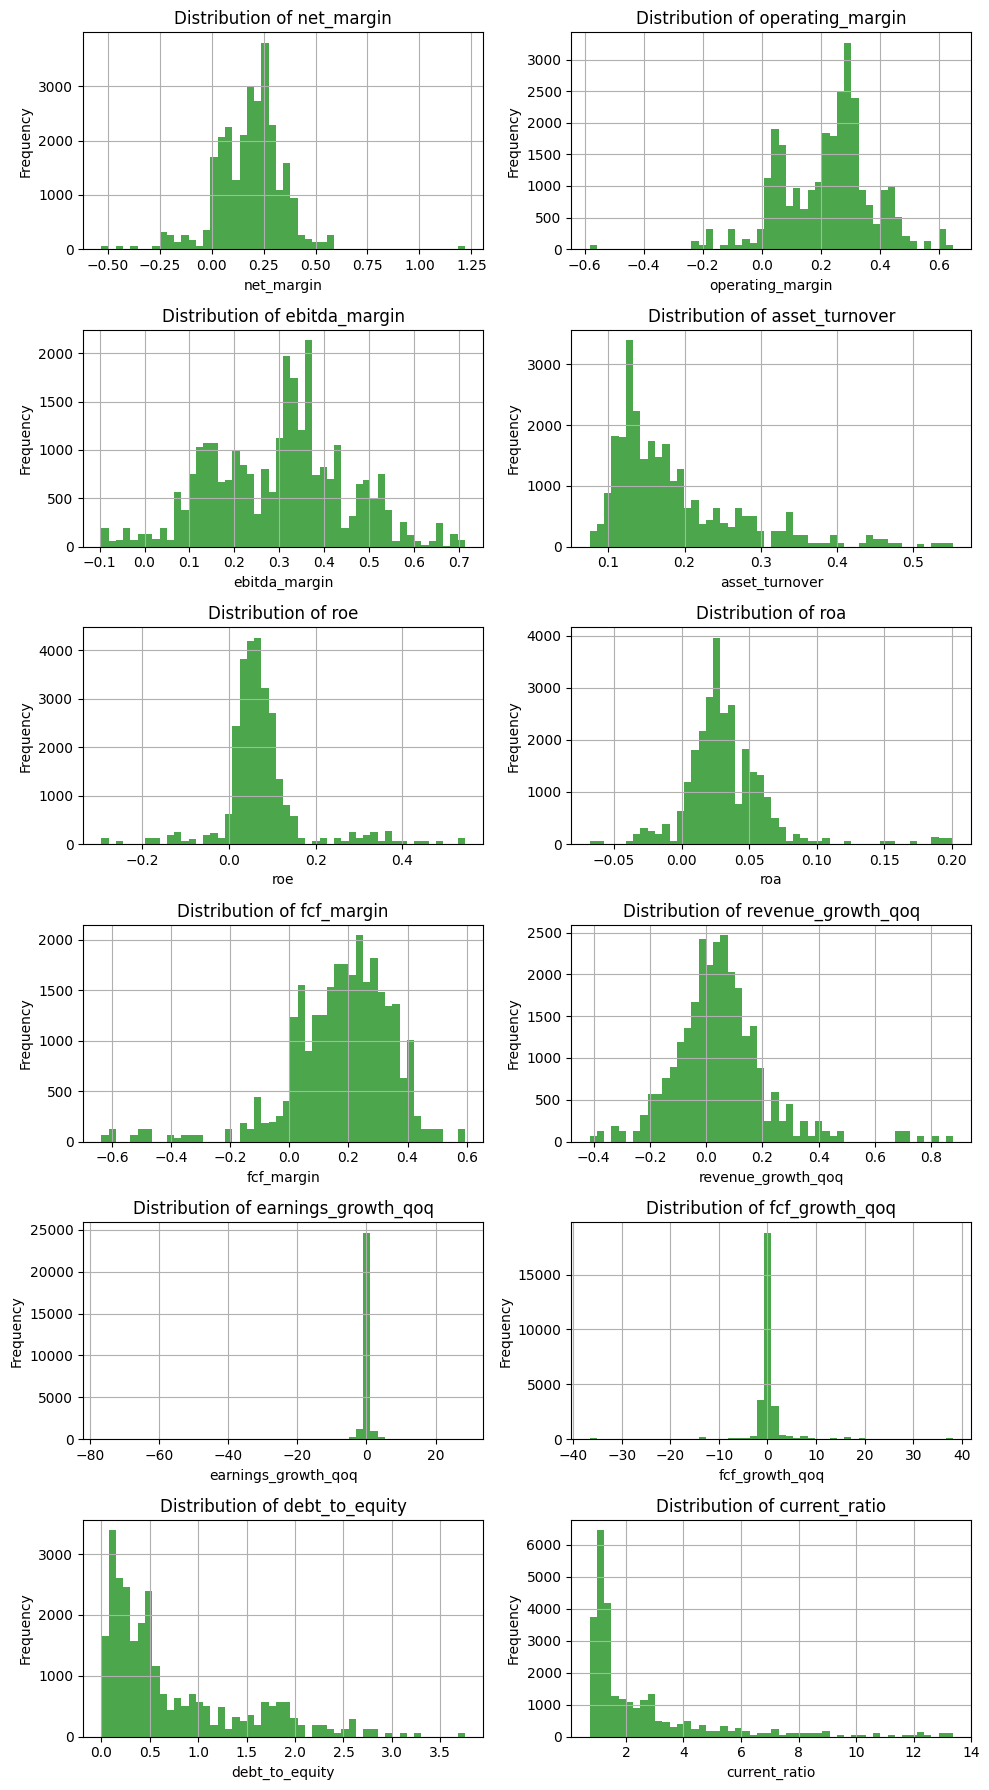

In [26]:
# fundamental distributions (2 plots per row, smaller)
n = len(fund_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(fund_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Macro Distribution

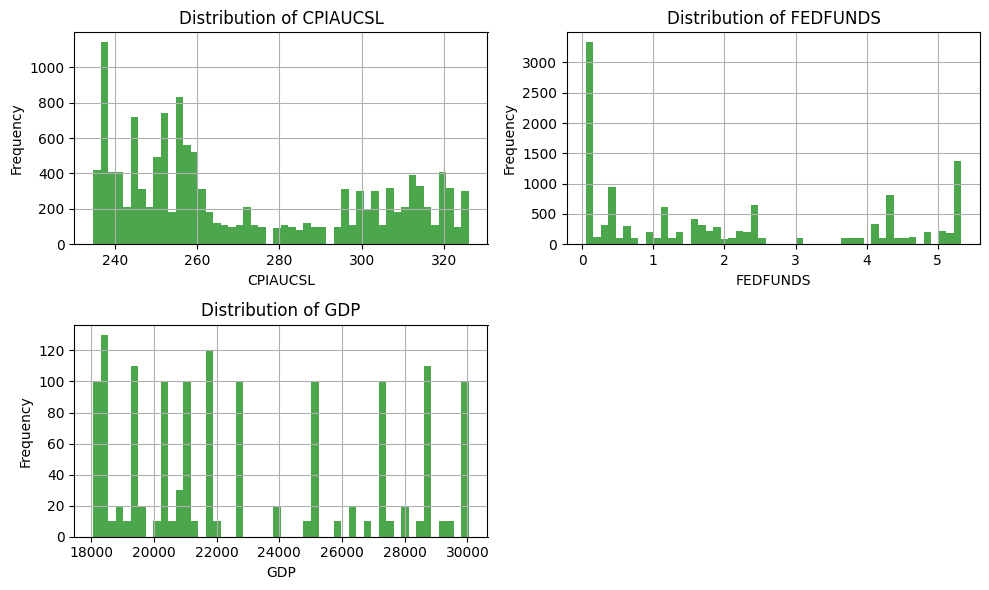

In [27]:
n = len(macro_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(macro_cols  ):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=50, color='green', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True)

# turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Volume Dist

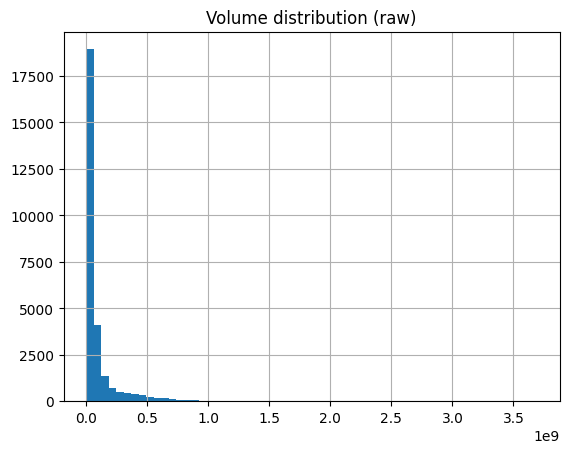

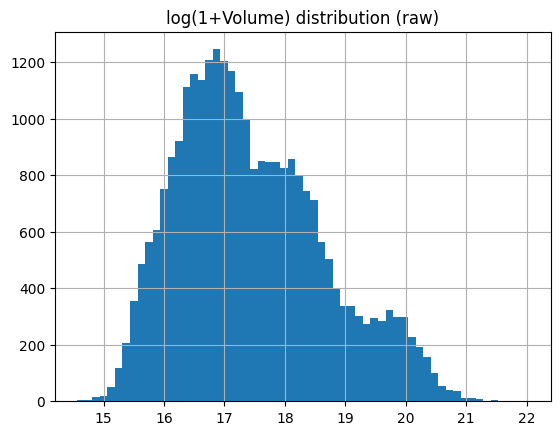

In [5]:
plt.figure()
df_raw["volume"].dropna().hist(bins=60)
plt.title("Volume distribution (raw)")
plt.show()

plt.figure()
np.log1p(df_raw["volume"].dropna()).hist(bins=60)
plt.title("log(1+Volume) distribution (raw)")
plt.show()


## Preprocessing

## Results

## Feature Engineering

## New Features

## Saving The File